# k-means clusering implemented
I recently watched *StatQuest: K-Means Clustering (https://www.youtube.com/watch?v=4b5d3muPQmA)* on YouTube for uni and decided to implement k-means myself in order to understand it better for my upcoming exam.

In [76]:
import math
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification

In [77]:
def calculate_distance(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

In [78]:
def set_centers(k, X):
    centers = []
    for i in range(k):
            j = np.random.randint(0, 500)
            while (X[j, 0], X[j, 1]) in centers:
                  j = np.random.randint(0, 500)
            centers.append((X[j, 0], X[j, 1]))
    return np.array(centers)


In [79]:
def assign_cluster(centers, X):
    y = []
    for i in range(len(X[:, 0])):
        min_distance = float("inf")
        cur_center = None
        for j in range(len(centers)):
            d = calculate_distance(centers[j], (X[i, 0], X[i, 1]))
            if d <= min_distance:
                min_distance = d
                cur_center = j
        y.append(cur_center)

    return np.array(y)

In [80]:
def calculate_cluster_mean(centers, X, y):
    new_centers = []

    for i in range(len(centers)):
        n = 0
        s_x = 0
        s_y = 0
        for j in range(len(y)):
            if i == y[j]:
                n += 1
                s_x += X[j, 0]
                s_y += X[j, 1]

        if n == 0:
            new_centers.append(centers[i])
        else:
            mean_x = s_x / n
            mean_y = s_y / n
            new_centers.append((mean_x, mean_y))

    return np.array(new_centers)


In [88]:
def k_means(k, X):
    centers = set_centers(k, X)
    y = assign_cluster(centers, X)


    i = 0
    prev_centers = []
    while not all(item in prev_centers for item in centers):
        prev_centers = centers
        centers = calculate_cluster_mean(centers, X, y)
        y = assign_cluster(centers, X)

        """print(i)
        i += 1
        plt.scatter(X[:, 0], X[:, 1], c=y)
        plt.scatter(centers[:, 0], centers[:, 1], color="red", marker="X")
        plt.show()"""
        
    return np.array(y), centers

In [82]:
X, y = make_classification(
    n_samples=500, 
    n_features=2,           
    n_informative=2, 
    n_redundant=0, 
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=1.8,
    random_state=1123344,
)

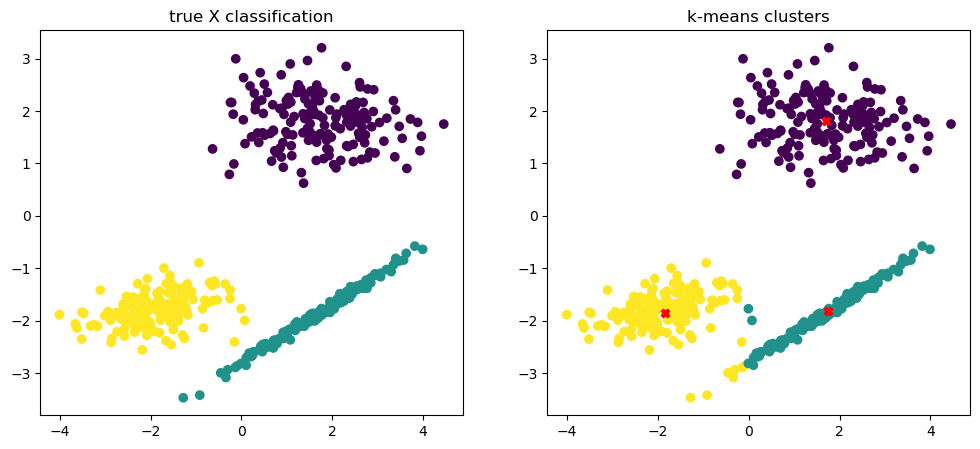

In [93]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


ax[0].set_title("true X classification")
ax[0].scatter(X[:, 0], X[:, 1], c=y)


c_y, centers = k_means(3, X)

ax[1].set_title("k-means clusters")
ax[1].scatter(X[:, 0], X[:, 1], c=c_y)
ax[1].scatter(centers[:, 0], centers[:, 1], color="red", marker="X")
plt.show()